Training fold 1 ...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 - Training Accuracy: 0.9750, Testing Accuracy: 1.0000
Training fold 2 ...
Fold 2 - Training Accuracy: 0.9750, Testing Accuracy: 0.9667
Training fold 3 ...
Fold 3 - Training Accuracy: 0.9833, Testing Accuracy: 0.9667
Training fold 4 ...
Fold 4 - Training Accuracy: 0.9833, Testing Accuracy: 0.9333
Training fold 5 ...
Fold 5 - Training Accuracy: 0.9750, Testing Accuracy: 1.0000

Average Training Accuracy: 0.9783
Average Testing Accuracy: 0.9733


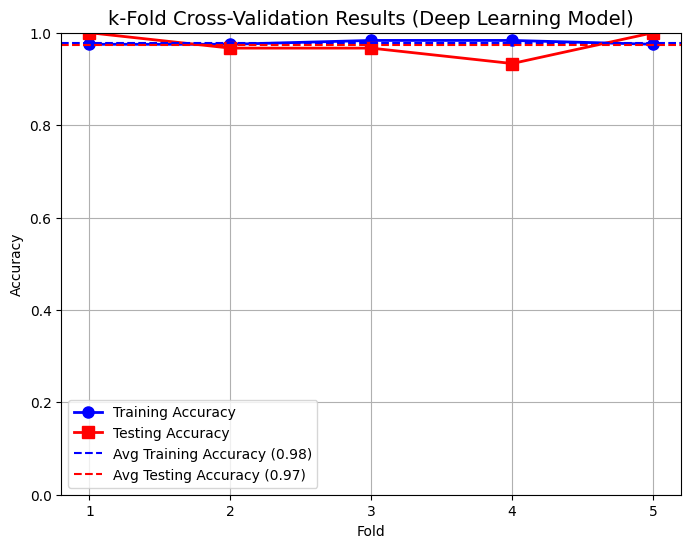

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

data = load_iris()
X = data.data
y = data.target
y = to_categorical(y, num_classes=3)

def create_model():
    model = Sequential()
    model.add(Dense(64, input_dim=4, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_accuracies = []
test_accuracies = []

for fold, (train_index, test_index) in enumerate(kf.split(X), start=1):
    print(f"Training fold {fold} ...")
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model = create_model()
    model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)
    train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
    print(f"Fold {fold} - Training Accuracy: {train_accuracy:.4f}, Testing Accuracy: {test_accuracy:.4f}")

average_train_accuracy = np.mean(train_accuracies)
average_test_accuracy = np.mean(test_accuracies)

print(f"\nAverage Training Accuracy: {average_train_accuracy:.4f}")
print(f"Average Testing Accuracy: {average_test_accuracy:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(range(1, 6), train_accuracies, marker='o', label='Training Accuracy', color='b', linestyle='-', linewidth=2, markersize=8)
ax.plot(range(1, 6), test_accuracies, marker='s', label='Testing Accuracy', color='r', linestyle='-', linewidth=2, markersize=8)
ax.axhline(y=average_train_accuracy, color='b', linestyle='--', label=f'Avg Training Accuracy ({average_train_accuracy:.2f})')
ax.axhline(y=average_test_accuracy, color='r', linestyle='--', label=f'Avg Testing Accuracy ({average_test_accuracy:.2f})')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('k-Fold Cross-Validation Results (Deep Learning Model)', fontsize=14)
ax.set_xticks(range(1, 6))
ax.set_ylim([0, 1])
ax.grid(True)
ax.legend()
plt.show()
